## ANN with no tool

Here well only go over the code and the math behind the ANN that i have implemented. The code is in the file `ANN_noTool.py` and it is a simple implementation of a feedforward neural network with one hidden layer. The code is not optimized for performance and is only meant for my **stupid** barin to understand it.

Btw. this is the tutorial that I followed: [GeeksForGeeks - ANN](https://www.geeksforgeeks.org/deep-learning/building-artificial-neural-networks-ann-from-scratch/)

---

### ReLu activation function

Well use ReLu for activation. You might have the same question as I had, **why do we need to activate the neurons, isn't it enough a "normal" function?** ($ y = w \cdot x + b$). The answer is no, if we don't activate the neurons, the output of the network will be a linear function of the input, and we won't be able to learn complex patterns in the data. It's basicly just a linear regression model.

In the end for aone neuron (e.q IL:n -> HL:m) we have: $$ ReLu(x_n) = max(0, b_{1_n} + x_n \cdot w_{1_{nm}}) $$

---

### Forword propagation

This is the process of calculating the output of the network given an input. We start with the input layer, and we calculate the output of each neuron in the hidden layer using the weights and biases. Then we apply the activation function to the output of each neuron in the hidden layer, and we repeat this process until we reach the output layer.

// TODO: add picture of the forword propagation

---

### Cost function

The cost function we use is the **bynary cross entropy**. This cost function is used for binary classification problems, and it measures the difference between the predicted output and the actual output. The formula for the binary cross entropy is: $$ C = -\frac{1}{N} \sum_{i=1}^{N} [y_i \cdot log(\hat{y}_i) + (1 - y_i) \cdot log(1 - \hat{y}_i)] $$ where $N$ is the number of samples, $y_i$ is the actual output, and $\hat{y}_i$ is the predicted output.

```py
def cost(self, Y, output):
	m = Y.shape[1]
	cost = -np.sum(Y * np.log(output) + (1 - Y) * np.log(1 - output)) / m
	return np.squeeze(cost) # removes any extra dimensions, returning the cost as a scalar
```

---

### Backpropagation

This is the process of calculating the gradients of the cost function with respect to the weights and biases, and then updating the weights and biases using gradient descent. 
$$ \nabla w_{ij} = \eta \cdot \delta_j \cdot y_i $$
$$ \delta_j^{hidden} = \sum_{k} \delta_k^{output} \cdot w_{jk}^{output} \cdot ReLu'(z_j) $$
$$ \delta_j^{output} = \hat{y}_j - y_j $$

```py
def backward(self, X, Y, cache):
	m = Y.shape[1]
	A1 = cache["A1"]
	A2 = cache["A2"]

	# we devide by m because this is a batch
	dZ2 = A2 - Y
	dW2 = np.dot(A1.T, dZ2) / m
	db2 = np.sum(dZ2, axis=0, keepdims=True) / m

	dZ1 = np.dot(dZ2, self.W2.T) * (A1 > 0)
	dW1 = np.dot(X.T, dZ1) / m
	db1 = np.sum(dZ1, axis=0, keepdims=True) / m

	return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}
```

In [1]:
from datasets import load_from_disk

dataset = load_from_disk("./data/filtered_dataset") 

In [ ]:
import numpy as np
from tqdm import tqdm
import cv2

def normalize_image_to_array(image):
	img = np.array(image).astype(np.uint8)
	img = cv2.resize(img, (64, 64)) # if you fallow thie homework good sir, do this in the database_maker.py when making the dataset
	img_1D = img.flatten()
	return img_1D / 255.0


In [3]:
X = np.array([normalize_image_to_array(img) for img in tqdm(dataset['image'])])
Y = dataset['label']

100%|██████████| 500/500 [10:06<00:00,  1.21s/it]


In [4]:
from sklearn.model_selection import train_test_split
from ANN_noTool import ANN_noTool

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

ann = ANN_noTool()
ann.init_weights(input_size=64*64*3, hidden_size=128, output_size=1)
ann.train(np.array(X_train), np.array(Y_train))

(400, 12288)
(400,)
Epoch 0, Cost: 0.8367
Epoch 100, Cost: 0.5226
Epoch 200, Cost: 0.4291
Epoch 300, Cost: 0.3660
Epoch 400, Cost: 0.3115
Epoch 500, Cost: 0.2608
Epoch 600, Cost: 0.2170
Epoch 700, Cost: 0.1801
Epoch 800, Cost: 0.1554
Epoch 900, Cost: 0.1294


Accuracy: 0.6300
Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.66      0.63        47
           1       0.67      0.60      0.63        53

    accuracy                           0.63       100
   macro avg       0.63      0.63      0.63       100
weighted avg       0.63      0.63      0.63       100

Confusion Matrix:


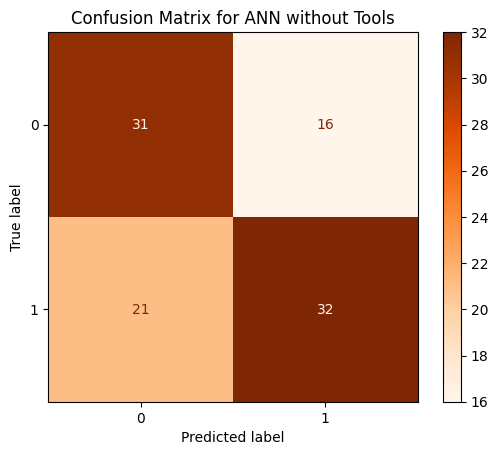

In [5]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt

predictions = ann.predict(X_test)

accuracy = accuracy_score(Y_test, predictions)
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:")
print(classification_report(Y_test, predictions))
print("Confusion Matrix:")
cm_ann = confusion_matrix(Y_test, predictions)
disp_ann = ConfusionMatrixDisplay(confusion_matrix=cm_ann).plot(cmap='Oranges')
plt.title("Confusion Matrix for ANN without Tools")
plt.show()

Welp, it's not that bad...

---

## CNN with no tool

A CNN (Convolutional Neural Network) is a type of ANN designed to process grid-like data such as images or videos. It uses convolutional and pooling layers to automatically extract features and reduce dimensionality.

Convolutional neural networks have three main kinds of layers, which are:
+ Convolutional layer
+ Pooling layer
+ Fully-connected layer

$$ output = \frac{input - filter + 2 \times padding}{stride} + 1 $$

Our model will have the following architecture:
+ input layer 											-> 64x64x3
+ convolution + ReLu: 									-> 62x62x8
+ pooling: MaxPool with size 2x2, stride 2 				-> 31x31x8
+ convolution + ReLu: 									-> 29x29x16
+ pooling: MaxPool with size 2x2, stride 2 				-> 14x14x16
+ flatten 												-> 3136
+ fully-connected + ReLu								-> 128	
+ output layer (sigmoid)								-> 1

---

### Convolutional layer

The convolutional layer applies a set of filters to the input image to extract features. Each filter is a small matrix that is slid over the input image, and at each position, the dot product of the filter and the input patch is calculated to produce a single value in the output feature map.

We will have multiples layes and a RBG matrix. So for every kernel we calculate a new matrix, and we will have 8 kernels, so we will have 8 matrices. Each matrix is called a feature map, and it represents the presence of a specific feature in the input image.

<p align="center">
	<img src="https://miro.medium.com/v2/resize:fit:1100/format:webp/0*0Oqq6rype7DU-P-x.gif" alt="convolution" width="500">
</p>


In [6]:
import numpy as np

def conv2d(input_matrix, kernel):
	input_height, input_width = input_matrix.shape	
	kernel_height, kernel_width = kernel.shape

	output_height = input_height - kernel_height + 1
	output_width = input_width - kernel_width + 1

	output_matrix = np.zeros((output_height, output_width))
	for i in range(output_height):
		for j in range(output_width):
			region = input_matrix[i:i+kernel_height, j:j+kernel_width]
			output_matrix[i, j] = np.sum(region * kernel)
	
	return output_matrix

def conv2d_rgb(input_matrix, kernel):
	"""
		input_matrix(H, W, C)
		kernel(KH, KW, C)
		output_matrix(H_out, W_out)
	"""
	input_height, input_width, input_channels = input_matrix.shape
	
	output_height = input_height - kernel.shape[0] + 1
	output_width = input_width - kernel.shape[1] + 1
	
	output_matrix = np.zeros((output_height, output_width))

	for channel in range(input_channels):
		output_matrix += conv2d(input_matrix[:, :, channel], kernel[:, :, channel])

	return output_matrix

def conv2d_multi_kernel(input_matrix, kernels, biases):
	"""
		input_matrix(H, W, C)
		kernels(N_kernels, KH, KW, C)
		biases(N_kernels, 1)
		output_matrix(H_out, W_out, N_kernels)
	"""
	input_height, input_width, _ = input_matrix.shape
	num_kernels = kernels.shape[0]
	
	output_height = input_height - kernels.shape[1] + 1
	output_width = input_width - kernels.shape[2] + 1
	
	output_matrix = np.zeros((output_height, output_width, num_kernels))

	for k in range(num_kernels):
		output_matrix[:, :, k] = conv2d_rgb(input_matrix, kernels[k]) + biases[k]

	return output_matrix

### ReLu activation function
Us having a matrix in the `np.maximum(0, matrix)`. So this will go over all the layers and will set all the negative values to 0, and keep all the positive values as they are. This is a simple way to introduce non-linearity into the model, which allows it to learn more complex patterns in the data. 

In [7]:
def relu(matrix):
	return np.maximum(0, matrix)

### MaxPooling layer

This layer makes the feature maps smaller by taking the maximum vlaue in a era (we will use 2x2 pooling). This helps to reduce the computational cost and also helps to make the model more robust to small translations in the input image.

In [8]:
def maxPooling(input_matrix, pool_size=2, stride=2):
	input_height, input_width, input_channels = input_matrix.shape
	
	output_height = (input_height - pool_size) // stride + 1
	output_width = (input_width - pool_size) // stride + 1
	
	output_matrix = np.zeros((output_height, output_width, input_channels))

	for channel in range(input_channels):
		for i in range(output_height):
			for j in range(output_width):
				h_start, h_end = i * stride, i * stride + pool_size
				w_start, w_end = j * stride, j * stride + pool_size

				region = input_matrix[h_start:h_end, w_start:w_end, channel]
				output_matrix[i, j, channel] = np.max(region)

	return output_matrix

### Flatten layer
This layer takes the output of the convolutional and pooling layers and flattens it into a 1D vector, which can then be fed into a ANN.

In [9]:
def flatten(input_matrix):
	return input_matrix.flatten()

### Sigmoid activation function
This is the activation function we will use in the output layer, since this is a binary classification problem. The sigmoid function maps the output to a value between 0 and 1, which can be interpreted as a probability of the input belonging to the positive class.

In [10]:
def sigmoid(matrix):
	return 1 / (1 + np.exp(-matrix))

### Forword propagation
All the layers are connected together.

In [25]:
def forward_pass(input_image, parameters):
	# Reshape the input image to (64, 64, 3)
	input_image = input_image.reshape(64, 64, 3)

	# Conv + ReLu
	Z1 = conv2d_multi_kernel(input_image, parameters['W1'], parameters['b1'])
	A1 = relu(Z1)
	
	# Pooling
	P1 = maxPooling(A1)

	# Conv + ReLu
	Z2 = conv2d_multi_kernel(P1, parameters['W2'], parameters['b2'])
	A2 = relu(Z2)

	# Pooling
	P2 = maxPooling(A2)

	# Flatten
	F = flatten(P2)

	# Fully connected + ReLu
	Z3 = np.dot(parameters['W3'], F) + parameters['b3']
	A3 = relu(Z3)

	# Output layer (sigmoid)
	Z4 = np.dot(parameters['W4'], A3) + parameters['b4']
	A4 = sigmoid(Z4)

	return A4, {'X': input_image, 'Z1': Z1, 'A1': A1, 'P1': P1, 'Z2': Z2, 'A2': A2, 'P2': P2, 'F': F, 'Z3': Z3, 'A3': A3, 'Z4': Z4}

### Initialization
The weights and biases of the network are initialized randomly.

In [12]:
def init_weights():
	params = {
		"W1": np.random.randn(8, 3, 3, 3) * 0.01,
		"b1": np.zeros((8,)),
		"W2": np.random.randn(16, 3, 3, 8) * 0.01,
		"b2": np.zeros((16,)),
		"W3": np.random.randn(128, 3136) * 0.01,
		"b3": np.zeros((128,)),
		"W4": np.random.randn(1, 128) * 0.01,
		"b4": np.zeros((1,))
	}
	return params

### Normalization

In [13]:
def normalize_image(image):
	img = np.array(image).astype(np.uint8)
	img = cv2.resize(img, (64, 64)) 
	return img / 255.0

### Before we continue

Let's put everything together and test the forward pass on one image to make sure the shapes are correct before touching backprop

In [14]:
from PIL import Image
from matplotlib import pyplot as plt

sample_image = Image.open("./data/sun_pic.jpeg")

image = normalize_image(sample_image)
label = 1 		# It's not edited

parameters = init_weights()
output, cache = forward_pass(image.flatten(), parameters)            

### Original output with debuging statements

```txt
(64, 64, 3)
12288
After Conv1 + ReLU:  (62, 62, 8)
After Pooling1:  (31, 31, 8)
After Conv2 + ReLU:  (29, 29, 16)
After Pooling2:  (14, 14, 16)
After Flattening:  (3136,)
After Fully Connected + ReLU:  (128,)
After Output Layer:  (1,)
Input shape:  (64, 64, 3)
Output:       [0.50000221]
Label:        1
```

## Backpropagation in CNN :P

Well, this is the part I don't think I will finish. However, I shall try!

---

### MaxPooling Backpropagation

During forward pass you took the max value from each 2x2 window. During backward pass you need to ask: "which pixel contributed to the output?". Only the that was the max gets the gradient and the rest get 0.

In [15]:
def maxPooling_backprop(dA, A, pool_size=2, stride=2):
	input_height, input_width, input_channels = A.shape
	
	output_height = (input_height - pool_size) // stride + 1
	output_width = (input_width - pool_size) // stride + 1
	
	dA_prev = np.zeros_like(A)

	for channel in range(input_channels):
		for i in range(output_height):
			for j in range(output_width):
				h_start, h_end = i * stride, i * stride + pool_size
				w_start, w_end = j * stride, j * stride + pool_size

				region = A[h_start:h_end, w_start:w_end, channel]
				max_val = np.max(region) # until now it;s just the max pooling forward pass, now we need to find which pixel contributed to the output

				mask = (region == max_val) # binary mask, max is 1 and the rest are 0
				dA_prev[h_start:h_end, w_start:w_end, channel] += mask * dA[i, j, channel]

	return dA_prev

### Convolutional layer backpropagation
> link [Convolutions and Backpropagations](https://pavisj.medium.com/convolutions-and-backpropagations-46026a8f5d2c)

### Updateing the weights

In [18]:
def update_params(params, gradients, learning_rate=0.01):
    params["W1"] -= learning_rate * gradients["dW1"]
    params["b1"] -= learning_rate * gradients["db1"]
    params["W2"] -= learning_rate * gradients["dW2"]
    params["b2"] -= learning_rate * gradients["db2"]
    params["W3"] -= learning_rate * gradients["dW3"]
    params["b3"] -= learning_rate * gradients["db3"]
    params["W4"] -= learning_rate * gradients["dW4"]
    params["b4"] -= learning_rate * gradients["db4"]
    return params

### Training the model

In [19]:
def train(X, Y, params, epochs=10, learning_rate=0.01):
    for epoch in range(epochs):
        total_loss = 0

        for i in range(len(X)):
            image = X[i]
            label = np.array([Y[i]])

            # forward
            output, cache = forward_pass(image, params)

            # loss
            loss = -np.mean(label * np.log(output + 1e-8) + (1 - label) * np.log(1 - output + 1e-8))
            total_loss += loss

            # backward
            gradients = backward_pass(output, label, params, cache)

            # update
            params = update_params(params, gradients, learning_rate)

            if i % 100 == 0:
                print(f"Epoch {epoch} | Image {i} | Loss: {loss:.4f}")

        print(f"Epoch {epoch} complete | Avg Loss: {total_loss/len(X):.4f}")

    return params